In [31]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

In [32]:
# load dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)
print(df.head())

     Month  Passengers
0  1949-01         112
1  1949-02         118
2  1949-03         132
3  1949-04         129
4  1949-05         121


In [33]:
# preprocessing 
data = df['Passengers'].values.reshape(-1, 1)

In [34]:
# scale data(RNN works better with scaled data)
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

In [35]:
# create sequences
def create_sequences(dataset, time_steps=10):
    X, y = [],[]
    for i in range(len(dataset)-time_steps):
        X.append(dataset[i:i + time_steps, 0])
        y.append(dataset[i + time_steps, 0])
    return np.array(X), np.array(y)
time_steps = 10
X, y = create_sequences(data_scaled, time_steps)

In [36]:
#reshape for RNN input
X = X.reshape(X.shape[0], X.shape[1], 1)

In [37]:
# Train- test split
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


In [38]:
# build RNN model
model = Sequential([
    SimpleRNN(50, activation='tanh', input_shape=(time_steps, 1)),
])
model.compile(optimizer='adam', loss='mse')

c:\Users\ABISHEK\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [39]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)


(107, 10, 1) (107,)
(27, 10, 1) (27,)


In [40]:
import numpy as np
X_train = np.array(X_train)
y_train = np.array(y_train)


In [41]:
# Example: split properly
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


In [42]:
# # Reshape labels to be 2D
# y_train = y_train.reshape(-1, 1)
# y_test = y_test.reshape(-1, 1)

# # Train model
# history = model.fit(
#     X_train, y_train,
#     epochs=50,
#     batch_size=16,
#     validation_data=(X_test, y_test)
# )


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

# Example: assume X and y are already prepared
X = np.array(X)   # shape (samples, timesteps, features)
y = np.array(y)   # shape (samples,)

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Reshape labels to (n_samples, 1) for regression/binary classification
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

# Build model
model = Sequential()
model.add(LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dense(1))  # single output per sample

# Compile with appropriate loss
# Use 'mse' for regression, 'binary_crossentropy' for binary classification
model.compile(optimizer=Adam(), loss='mse', metrics=['mae'])

# Train
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test)
)


Train: (107, 10, 1) (107, 1)
Test: (27, 10, 1) (27, 1)
Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - loss: 0.1374 - mae: 0.3050 - val_loss: 0.0376 - val_mae: 0.1431
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0346 - mae: 0.1386 - val_loss: 0.0119 - val_mae: 0.0904
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0206 - mae: 0.1239 - val_loss: 0.0242 - val_mae: 0.1443
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0186 - mae: 0.1178 - val_loss: 0.0105 - val_mae: 0.0812
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0139 - mae: 0.0899 - val_loss: 0.0093 - val_mae: 0.0645
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0151 - mae: 0.0892 - val_loss: 0.0089 - val_mae: 0.0650
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0131 - mae: 0.0881 - val_loss: 0.0099 - val_mae: 0.0793
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0132 - mae: 0.0921 - val_loss: 0.0101 - val_mae: 0.0806
Epoch 9/50
7/7 ━━━━━━━━━━

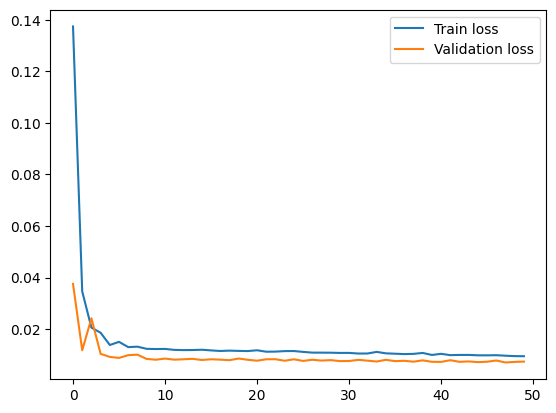

In [45]:
# Evaluate model
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.legend()
plt.show()

In [46]:
# prediction
y_pred = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step


In [47]:
# Inverse transform to original scale
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_inv = scaler.inverse_transform(y_pred)

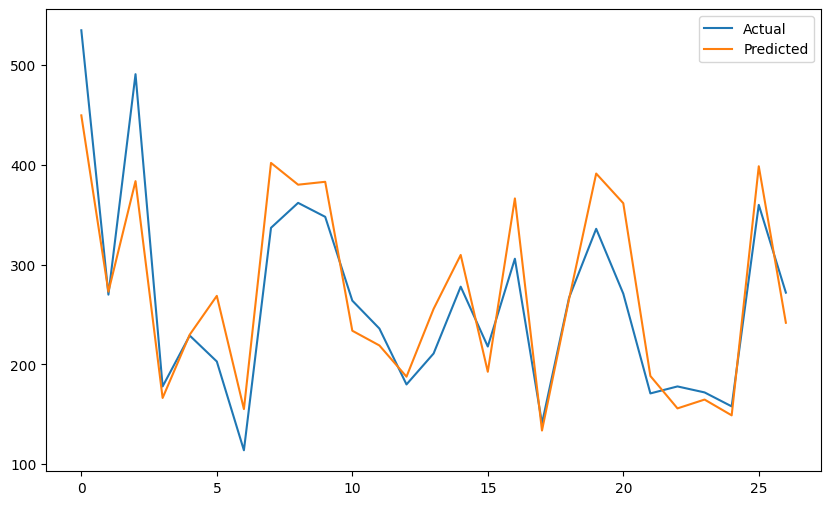

In [48]:
# visualization
plt.figure(figsize=(10, 6))
plt.plot(y_test_inv, label='Actual')
plt.plot(y_pred_inv, label='Predicted')
plt.legend()
plt.show()

In [49]:
last_sequence = data_scaled[-time_steps:]
last_sequence = last_sequence.reshape(1, time_steps, 1)
next_value = model.predict(last_sequence)
print("Next predicted passenger count:", scaler.inverse_transform(next_value)[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step
Next predicted passenger count: 481.59406
